# Human–LLM annotation agreement

## Objective

This notebook measures agreement between blinded human annotations and LLM-as-a-judge annotations for candidate MCQA duplicate pairs. The labels are nominal categories, so Pearson or Spearman correlation would impose an unjustified ordering. Instead, the analysis reports observed agreement and Cohen's kappa, which adjusts agreement for the overlap expected from the annotators' marginal label distributions.

Two views are evaluated:

1. **Exact semantic label:** `duplicate`, `related_but_distinct`, `distinct`, or `unsure`.
2. **Operational deduplication decision:** `duplicate` versus `not_duplicate`.

The human annotation is treated as the reference point for comparison, not as objective ground truth.

In [1]:
from __future__ import annotations

import math
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

LABELS = ("duplicate", "related_but_distinct", "distinct", "unsure")
BINARY_LABELS = ("duplicate", "not_duplicate")
REQUIRED_COLUMNS = (
    "pair_key",
    "left_exam",
    "right_exam",
    "left_question",
    "right_question",
    "left_choices",
    "right_choices",
    "left_answer",
    "right_answer",
    "label",
    "notes",
)
ANNOTATION_COLUMNS = {"label", "notes"}

sns.set_theme(context="paper", style="whitegrid", font_scale=1.05)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")

REPO_ROOT = find_repo_root(Path.cwd())
ANNOTATION_DIR = REPO_ROOT / "assets" / "annotations"
HUMAN_PATH = ANNOTATION_DIR / "manual_labels_blind_10_human_annotated.csv"
LLM_PATH = ANNOTATION_DIR / "manual_labels_blind_10_llm_annotated.csv"

print(f"Repository: {REPO_ROOT}")
print(f"Human annotations: {HUMAN_PATH}")
print(f"LLM annotations: {LLM_PATH}")
print(f"Python: {platform.python_version()}")

Repository: /home/aluno_paulosantana/repositories/mmlu-pt
Human annotations: /home/aluno_paulosantana/repositories/mmlu-pt/assets/annotations/manual_labels_blind_10_human_annotated.csv
LLM annotations: /home/aluno_paulosantana/repositories/mmlu-pt/assets/annotations/manual_labels_blind_10_llm_annotated.csv
Python: 3.12.3


## 1. Load and validate the paired annotations

Agreement is meaningful only when both files describe exactly the same pairs. The checks below reject missing fields, empty or invalid annotations, duplicate keys, different key sets, and any change to source content between the files. Rows are aligned exclusively through `pair_key`; CSV row order is irrelevant.

In [2]:
def load_annotations(path: Path, annotator: str) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(f"{annotator} annotation file not found: {path}")

    frame = pd.read_csv(path, keep_default_na=False)
    missing_columns = sorted(set(REQUIRED_COLUMNS) - set(frame.columns))
    if missing_columns:
        raise ValueError(f"{annotator} annotations are missing columns: {missing_columns}")
    if frame.empty:
        raise ValueError(f"{annotator} annotation file is empty.")
    if frame["pair_key"].astype(str).str.strip().eq("").any():
        raise ValueError(f"{annotator} annotations contain empty pair keys.")
    if frame["pair_key"].duplicated().any():
        duplicate_keys = frame.loc[frame["pair_key"].duplicated(keep=False), "pair_key"].unique()
        raise ValueError(f"{annotator} annotations contain duplicate pair keys: {duplicate_keys[:5].tolist()}")

    frame["label"] = frame["label"].astype(str).str.strip()
    frame["notes"] = frame["notes"].astype(str).str.strip()
    invalid_labels = sorted(set(frame["label"]) - set(LABELS))
    if invalid_labels:
        raise ValueError(f"{annotator} annotations contain invalid or empty labels: {invalid_labels}")
    if frame["notes"].eq("").any():
        raise ValueError(f"{annotator} annotations contain empty notes.")
    return frame

human = load_annotations(HUMAN_PATH, "Human")
llm = load_annotations(LLM_PATH, "LLM")

if set(human.columns) != set(llm.columns):
    human_only = sorted(set(human.columns) - set(llm.columns))
    llm_only = sorted(set(llm.columns) - set(human.columns))
    raise ValueError(f"Annotation schemas differ. Human-only: {human_only}; LLM-only: {llm_only}")

human_keys = set(human["pair_key"])
llm_keys = set(llm["pair_key"])
if human_keys != llm_keys:
    missing_from_llm = sorted(human_keys - llm_keys)
    missing_from_human = sorted(llm_keys - human_keys)
    raise ValueError(
        "Annotation files contain different pair keys. "
        f"Missing from LLM: {missing_from_llm[:5]}; missing from human: {missing_from_human[:5]}"
    )

source_columns = [column for column in human.columns if column not in ANNOTATION_COLUMNS and column != "pair_key"]
human_source = human.set_index("pair_key")[source_columns].sort_index()
llm_source = llm.set_index("pair_key")[source_columns].sort_index()
different_fields = [column for column in source_columns if not human_source[column].equals(llm_source[column])]
if different_fields:
    raise ValueError(f"Source fields differ between annotation files: {different_fields}")

paired = (
    human.rename(columns={"label": "human_label", "notes": "human_notes"})
    .merge(
        llm[["pair_key", "label", "notes"]].rename(
            columns={"label": "llm_label", "notes": "llm_notes"}
        ),
        on="pair_key",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("pair_key")
    .reset_index(drop=True)
)

validation_summary = pd.Series(
    {
        "paired records": len(paired),
        "unique pair keys": paired["pair_key"].nunique(),
        "source fields checked": len(source_columns),
        "human labels complete": human["label"].isin(LABELS).all(),
        "LLM labels complete": llm["label"].isin(LABELS).all(),
        "source fields identical": not different_fields,
    },
    name="value",
)
display(validation_summary.to_frame())

,value
paired records,47
unique pair keys,47
source fields checked,8
human labels complete,True
LLM labels complete,True
source fields identical,True


## 2. Label distributions

Marginal distributions provide context for raw agreement and determine the chance-agreement term in Cohen's kappa. Categories absent from either annotation are retained with a count of zero.

,human_count,llm_count,human_pct,llm_pct
label,,,,
duplicate,22,22,46.8085,46.8085
related_but_distinct,25,24,53.1915,51.0638
distinct,0,1,0.0000,2.1277
unsure,0,0,0.0000,0.0000


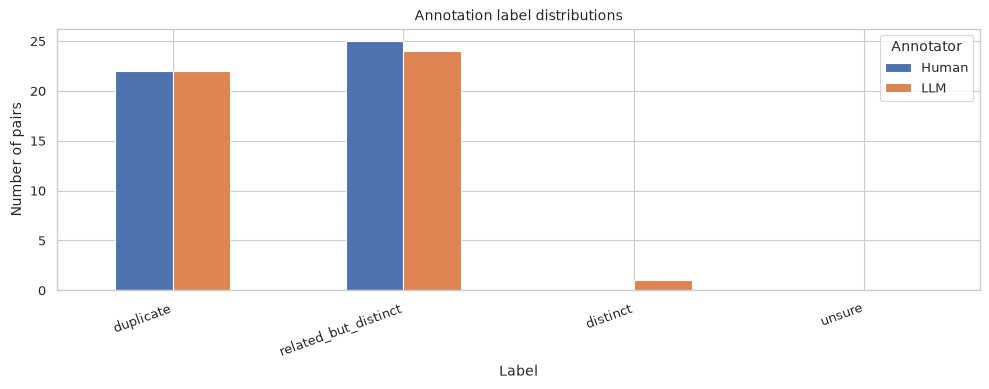

In [3]:
distribution = pd.DataFrame(
    {
        "human_count": paired["human_label"].value_counts().reindex(LABELS, fill_value=0),
        "llm_count": paired["llm_label"].value_counts().reindex(LABELS, fill_value=0),
    }
)
distribution["human_pct"] = 100 * distribution["human_count"] / len(paired)
distribution["llm_pct"] = 100 * distribution["llm_count"] / len(paired)
distribution.index.name = "label"
display(distribution)

distribution[["human_count", "llm_count"]].plot.bar(
    figsize=(10, 4), color=["#4C72B0", "#DD8452"]
)
plt.title("Annotation label distributions")
plt.xlabel("Label")
plt.ylabel("Number of pairs")
plt.xticks(rotation=20, ha="right")
plt.legend(["Human", "LLM"], title="Annotator")
plt.tight_layout()
plt.show()

## 3. Agreement metrics

Observed agreement is the proportion of pairs assigned the same label. Its 95% Wilson interval quantifies sampling uncertainty for that proportion. Cohen's kappa is defined as $\kappa=(p_o-p_e)/(1-p_e)$, where $p_o$ is observed agreement and $p_e$ is agreement expected from the two marginal distributions.

Kappa is reported without imposing ordinal weights because the semantic labels do not form a defensible numerical scale. The binary view maps every non-`duplicate` label—including `unsure`—to `not_duplicate`.

In [4]:
def make_confusion_matrix(
    reference: pd.Series,
    prediction: pd.Series,
    labels: tuple[str, ...],
) -> pd.DataFrame:
    reference_category = pd.Categorical(reference, categories=labels)
    prediction_category = pd.Categorical(prediction, categories=labels)
    matrix = pd.crosstab(
        reference_category,
        prediction_category,
        rownames=["Human"],
        colnames=["LLM"],
        dropna=False,
    )
    return matrix.reindex(index=labels, columns=labels, fill_value=0)

def wilson_interval(successes: int, total: int, z: float = 1.959963984540054) -> tuple[float, float]:
    if total <= 0:
        return np.nan, np.nan
    proportion = successes / total
    denominator = 1 + z**2 / total
    center = (proportion + z**2 / (2 * total)) / denominator
    margin = z * math.sqrt(
        proportion * (1 - proportion) / total + z**2 / (4 * total**2)
    ) / denominator
    return center - margin, center + margin

def agreement_metrics(matrix: pd.DataFrame, analysis: str) -> dict[str, float | int | str]:
    values = matrix.to_numpy(dtype=float)
    total = int(values.sum())
    agreements = int(np.trace(values))
    observed = agreements / total
    expected = float((values.sum(axis=1) * values.sum(axis=0)).sum() / total**2)
    kappa = (observed - expected) / (1 - expected) if expected < 1 else np.nan
    lower, upper = wilson_interval(agreements, total)
    return {
        "analysis": analysis,
        "pairs": total,
        "agreements": agreements,
        "observed_agreement": observed,
        "agreement_ci_lower": lower,
        "agreement_ci_upper": upper,
        "expected_agreement": expected,
        "cohen_kappa": kappa,
    }

multiclass_matrix = make_confusion_matrix(
    paired["human_label"], paired["llm_label"], LABELS
)
paired["human_binary"] = np.where(
    paired["human_label"].eq("duplicate"), "duplicate", "not_duplicate"
)
paired["llm_binary"] = np.where(
    paired["llm_label"].eq("duplicate"), "duplicate", "not_duplicate"
)
binary_matrix = make_confusion_matrix(
    paired["human_binary"], paired["llm_binary"], BINARY_LABELS
)

metrics = pd.DataFrame(
    [
        agreement_metrics(multiclass_matrix, "Exact semantic label"),
        agreement_metrics(binary_matrix, "Duplicate vs. not_duplicate"),
    ]
).set_index("analysis")

display(metrics.style.format({
    "observed_agreement": "{:.2%}",
    "agreement_ci_lower": "{:.2%}",
    "agreement_ci_upper": "{:.2%}",
    "expected_agreement": "{:.2%}",
    "cohen_kappa": "{:.4f}",
}))

,pairs,agreements,observed_agreement,agreement_ci_lower,agreement_ci_upper,expected_agreement,cohen_kappa
analysis,,,,,,,
Exact semantic label,47,46,97.87%,88.89%,99.62%,49.07%,0.9582
Duplicate vs. not_duplicate,47,47,100.00%,92.44%,100.00%,50.20%,1.0000


## 4. Confusion matrices

Rows are human annotations and columns are LLM annotations. Diagonal cells are agreements; off-diagonal cells identify the direction of each disagreement.

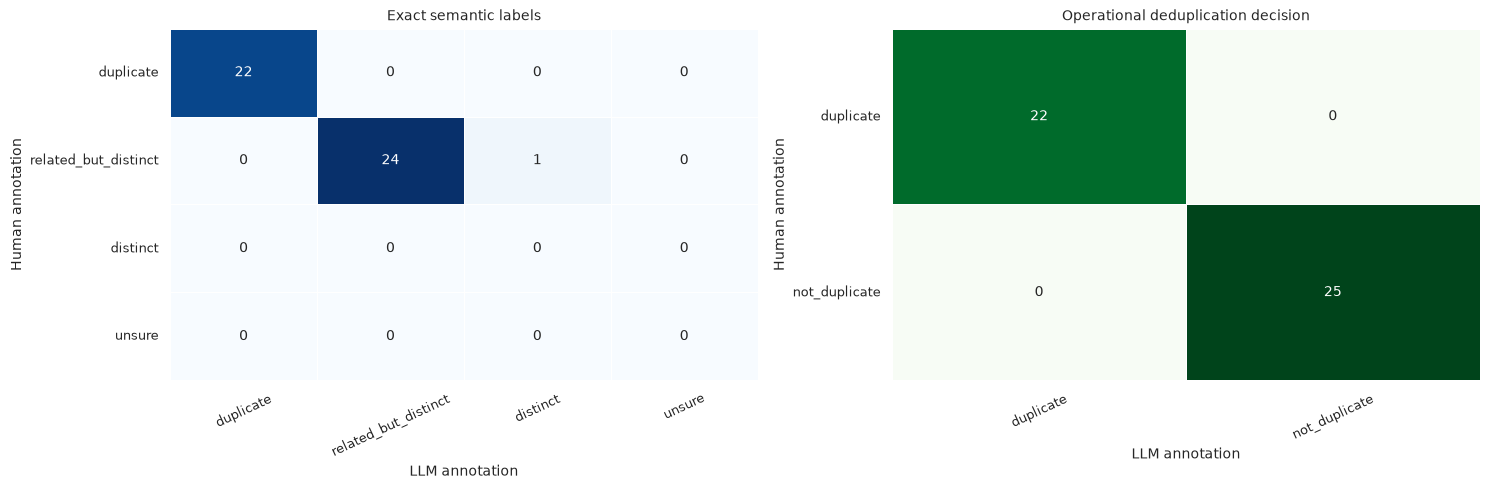

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(
    multiclass_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
    linewidths=0.5, linecolor="white", ax=axes[0],
)
axes[0].set_title("Exact semantic labels")
axes[0].set_xlabel("LLM annotation")
axes[0].set_ylabel("Human annotation")
axes[0].tick_params(axis="x", rotation=25)
axes[0].tick_params(axis="y", rotation=0)

sns.heatmap(
    binary_matrix, annot=True, fmt="d", cmap="Greens", cbar=False,
    linewidths=0.5, linecolor="white", ax=axes[1],
)
axes[1].set_title("Operational deduplication decision")
axes[1].set_xlabel("LLM annotation")
axes[1].set_ylabel("Human annotation")
axes[1].tick_params(axis="x", rotation=25)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

## 5. Disagreement audit

The table below retains both rationales and compact previews of the source questions so every off-diagonal result can be inspected directly. Full source text remains available through the corresponding `pair_key` in the input CSV files.

In [6]:
def compact_preview(value: str, max_characters: int = 240) -> str:
    normalized = " ".join(str(value).split())
    return normalized if len(normalized) <= max_characters else normalized[: max_characters - 1] + "…"

disagreements = paired.loc[paired["human_label"].ne(paired["llm_label"])].copy()
disagreements["left_question_preview"] = disagreements["left_question"].map(compact_preview)
disagreements["right_question_preview"] = disagreements["right_question"].map(compact_preview)
disagreement_view = disagreements[[
    "pair_key",
    "left_exam",
    "right_exam",
    "human_label",
    "llm_label",
    "human_notes",
    "llm_notes",
    "left_question_preview",
    "right_question_preview",
]]

display(Markdown(f"**Exact-label disagreements:** {len(disagreement_view):,} of {len(paired):,} pairs."))
display(disagreement_view)

**Exact-label disagreements:** 1 of 47 pairs.

,pair_key,left_exam,right_exam,human_label,llm_label,human_notes,llm_notes,left_question_preview,right_question_preview
11,1365056265e52a0958fe9587ea02f97ec7691f0c73d3c44cf171c10090eaf4d8::b34559c53f2e74584ed71c411f146a544a6d8c5d9a7cf4b97d0f6d23ab7f77b0,BACEN,BACEN,related_but_distinct,distinct,"Same base text, but with different questions.","The left question tests rules governing individual employment contracts, while the right tests constitutional provisions concerning the Executive Branch and...","• Nas questões a seguir, marque, para cada uma, a única opção correta, de acordo com o respectivo comando. Para as devidas marcações, use a Folha de Respost...","• Nas questões a seguir, marque, para cada uma, a única opção correta, de acordo com o respectivo comando. Para as devidas marcações, use a Folha de Respost..."


## 6. Interpretation

Agreement estimates should be interpreted together with their sample size and uncertainty interval. The multiclass result measures reproduction of the exact human semantic category. The binary result answers the narrower operational question of whether the LLM would make the same duplicate-removal decision. Neither result measures recall on pairs that were never selected for annotation, and agreement with one human annotator does not establish objective correctness.

In [7]:
exact = metrics.loc["Exact semantic label"]
binary = metrics.loc["Duplicate vs. not_duplicate"]
binary_disagreements = int((paired["human_binary"] != paired["llm_binary"]).sum())

interpretation = f"""
### Result

- **Exact semantic labels:** {int(exact['agreements'])}/{int(exact['pairs'])} pairs agree ({exact['observed_agreement']:.2%}; 95% Wilson CI {exact['agreement_ci_lower']:.2%}–{exact['agreement_ci_upper']:.2%}), with Cohen's kappa = {exact['cohen_kappa']:.4f}.
- **Operational duplicate decision:** {int(binary['agreements'])}/{int(binary['pairs'])} pairs agree ({binary['observed_agreement']:.2%}; 95% Wilson CI {binary['agreement_ci_lower']:.2%}–{binary['agreement_ci_upper']:.2%}), with Cohen's kappa = {binary['cohen_kappa']:.4f}.
- There are **{len(disagreements)} exact-label disagreement(s)** and **{binary_disagreements} duplicate-decision disagreement(s)**.

The distinction between exact-label and binary agreement is important: a disagreement between two non-duplicate categories affects semantic label fidelity but does not change the operational deduplication decision. These results apply only to the {len(paired)} annotated candidate pairs in these files.
"""
display(Markdown(interpretation))


### Result

- **Exact semantic labels:** 46/47 pairs agree (97.87%; 95% Wilson CI 88.89%–99.62%), with Cohen's kappa = 0.9582.
- **Operational duplicate decision:** 47/47 pairs agree (100.00%; 95% Wilson CI 92.44%–100.00%), with Cohen's kappa = 1.0000.
- There are **1 exact-label disagreement(s)** and **0 duplicate-decision disagreement(s)**.

The distinction between exact-label and binary agreement is important: a disagreement between two non-duplicate categories affects semantic label fidelity but does not change the operational deduplication decision. These results apply only to the 47 annotated candidate pairs in these files.
